In [15]:
# ============================================================================
# DISSERTATION TABLES — paste this whole block into ONE Jupyter cell and run.
#
# Then, in the NEXT cell, run:
#
#     df = run("/Users/chris/Downloads/Compiled_Metric_Analysis.xlsx")
#
#   -> displays Table 1 (full per-offense) and Table 3 (summary stats)
#      inline in the notebook. Nothing is saved to disk.
#
# To ALSO save the SVG files (when you're happy with them):
#
#     df = run("/Users/chris/Downloads/Compiled_Metric_Analysis.xlsx",
#              "/Users/chris/Downloads/tables_output")
#
# Data-handling rules (citable in a methods section):
#   * Cells stored as "n/51 (xx.xx%)" are parsed for count and percentage.
#   * Annotator names embedded in offense labels are stripped.
#   * The placeholder first row and rows marked REJECTED are excluded
#     (listed in the printout; also written to exclusions.txt when saving).
#   * NULL expert-review cells render as an em dash, footnoted.
# ============================================================================

import io
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------------

METRICS = [
    "LLM Disagreement",
    "Law Type: Statute",
    "Law Type: Case Law",
    "Law Type: No Landmark Case",
    "Law Type: Missing Data",
    "Expert: Tagged for Review",
    "Expert: Approved",
    "Expert: Rejected",
    "Expert: Repair/Adjust",
]

CELL_RE = re.compile(r"^\s*(\d+)\s*/\s*(\d+)\s*\(\s*([\d.]+)\s*%\s*\)\s*$")
ANNOTATORS = ["julie", "amal", "chloe", "daniel", "chris", "mabel"]

plt.rc("font", family="serif", serif=["Times New Roman", "DejaVu Serif"])
plt.rc("svg", fonttype="none")  # keep text as real text inside the SVG


# ----------------------------------------------------------------------------
# Parsing / cleaning
# ----------------------------------------------------------------------------

def parse_cell(value):
    """Parse 'n/51 (xx.xx%)' -> (count, total, pct). NULL/blank -> NaNs."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return (np.nan, np.nan, np.nan)
    s = str(value).strip()
    if s.upper() in {"NULL", "", "NA", "N/A"}:
        return (np.nan, np.nan, np.nan)
    m = CELL_RE.match(s)
    if not m:
        raise ValueError(f"Unparseable cell: {value!r}")
    return (int(m.group(1)), int(m.group(2)), float(m.group(3)))


def clean_offense_name(raw):
    """Strip annotator names and numbering artifacts; normalize labels."""
    name = str(raw).strip()
    name = re.sub(r"\(REJECTED[^)]*\)", "", name, flags=re.IGNORECASE)
    for person in ANNOTATORS:
        name = re.sub(rf"[_\-\s]*{person}[_\s]*$", "", name, flags=re.IGNORECASE)
    name = re.sub(r"^(Offense|Law)[\s_]*(\d+)[\s_\-]*", r"\1 \2 - ",
                  name, flags=re.IGNORECASE)
    name = re.sub(r"\s{2,}", " ", name).strip(" -_")
    tokens = name.split(" ")
    fixed = [t.title() if (t.isupper() and len(t) > 3) else t for t in tokens]
    return " ".join(fixed)


def load_data(xlsx_path):
    """Load, clean, and numeric-ify the workbook. Returns (df, exclusions)."""
    raw = pd.read_excel(xlsx_path)
    raw = raw.rename(columns={raw.columns[0]: "Offense"})

    exclusions, keep_rows = [], []
    for _, row in raw.iterrows():
        label = str(row["Offense"]).strip()
        if label.lower().startswith("compiled_metric"):
            exclusions.append(f"{label}  [placeholder/summary row]")
            continue
        if "rejected" in label.lower():
            exclusions.append(f"{label}  [marked rejected in source data]")
            continue
        keep_rows.append(row)

    df = pd.DataFrame(keep_rows).reset_index(drop=True)
    df["Offense"] = df["Offense"].map(clean_offense_name)

    for col in METRICS:
        parsed = df[col].map(parse_cell)
        df[f"{col} (n)"] = [p[0] for p in parsed]
        df["N"] = [p[1] for p in parsed]
        df[f"{col} (%)"] = [p[2] for p in parsed]
    return df, exclusions


def fmt_pct(x, decimals=1):
    return "—" if pd.isna(x) else f"{x:.{decimals}f}"


# ----------------------------------------------------------------------------
# Core SVG table renderer (booktabs style: horizontal rules only)
# ----------------------------------------------------------------------------

def render_table_svg(
    out_path,          # Path to save, or None for display-only
    col_headers,
    rows,
    col_widths,        # relative widths per column
    col_aligns,        # 'l' or 'r' per column
    title="",
    footnote="",
    fontsize=8.5,
    row_height_in=0.19,
    fig_width=None,
):
    n_rows = len(rows)
    widths = np.array(col_widths, dtype=float)
    widths /= widths.sum()
    x_pos = np.concatenate([[0.0], np.cumsum(widths)])

    header_h = row_height_in * 1.4
    title_h = 0.42 if title else 0.05
    foot_h = 0.30 if footnote else 0.08
    fig_h = title_h + header_h + n_rows * row_height_in + foot_h
    if fig_width is not None:
        fig_w = fig_width
    else:
        widest = max(sum(len(str(c)) for c in r) for r in rows + [col_headers])
        fig_w = min(14.0, max(5.0, widest * 0.085))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    y_top = 1.0 - (title_h / fig_h)
    hdr_frac = header_h / fig_h
    row_frac = (n_rows * row_height_in) / fig_h / max(n_rows, 1)

    if title:
        ax.text(0.0, 1.0, title, ha="left", va="top",
                fontsize=fontsize + 0.5, wrap=True)

    rule = dict(color="black", clip_on=False)
    ax.plot([0, 1], [y_top, y_top], lw=1.2, **rule)      # toprule
    y_mid = y_top - hdr_frac
    ax.plot([0, 1], [y_mid, y_mid], lw=0.6, **rule)      # midrule

    def cell_x(j):
        pad = 0.006
        if col_aligns[j] == "r":
            return x_pos[j + 1] - pad, "right"
        return x_pos[j] + pad, "left"

    for j, h in enumerate(col_headers):
        x, ha = cell_x(j)
        ax.text(x, y_top - hdr_frac / 2, h, ha=ha, va="center",
                fontsize=fontsize, fontweight="bold")

    for i, r in enumerate(rows):
        y = y_mid - (i + 0.5) * row_frac
        for j, c in enumerate(r):
            x, ha = cell_x(j)
            ax.text(x, y, str(c), ha=ha, va="center", fontsize=fontsize)

    y_bot = y_mid - n_rows * row_frac
    ax.plot([0, 1], [y_bot, y_bot], lw=1.2, **rule)      # bottomrule

    if footnote:
        ax.text(0.0, y_bot - 0.5 * (foot_h / fig_h), footnote,
                ha="left", va="center", fontsize=fontsize - 1.3,
                style="italic")

    if out_path is None:
        buf = io.StringIO()
        fig.savefig(buf, format="svg", bbox_inches="tight", pad_inches=0.06)
        plt.close(fig)
        return buf.getvalue()          # raw SVG markup, nothing saved
    fig.savefig(out_path, format="svg", bbox_inches="tight", pad_inches=0.06)
    plt.close(fig)
    print(f"  wrote {out_path.name}")
    return out_path


# ----------------------------------------------------------------------------
# Table 1: full per-offense table
# ----------------------------------------------------------------------------

# Columns shown in Table 1: (source metric, display header)
TABLE1_COLS = [
    ("LLM Disagreement", "LLM Disagreement"),
    ("Law Type: Statute", "Statute"),
    ("Expert: Tagged for Review", "Tagged for Expert Review"),
    ("Expert: Rejected", "Expert: Rejected"),
]


def option1_full(df, outdir=None):
    headers = ["Offense"] + [h for _, h in TABLE1_COLS]
    rows = [
        [r["Offense"]] + [fmt_pct(r[f"{c} (%)"]) for c, _ in TABLE1_COLS]
        for _, r in df.iterrows()
    ]
    return render_table_svg(
        None if outdir is None else outdir / "option1_full_table.svg",
        headers, rows,
        col_widths=[4.2, 1.7, 1.2, 2.1, 1.5],
        col_aligns=["l"] + ["r"] * len(TABLE1_COLS),
        title="Table 1. Per-offense annotation metrics "
              "(% of N = 51 jurisdictions per offense).",
        footnote="Em dash (—) denotes expert review pending.",
        fontsize=7.8,
        row_height_in=0.165,
        fig_width=11.0,
    )


# ----------------------------------------------------------------------------
# Table 3: summary statistics
# ----------------------------------------------------------------------------

# Metrics shown in Table 3
TABLE3_METRICS = [
    "LLM Disagreement",
    "Law Type: Statute",
    "Expert: Tagged for Review",
    "Expert: Rejected",
]


def option3_summary(df, outdir=None):
    headers = ["Metric", "k", "Mean", "Median", "SD", "Min", "Max"]
    rows = []
    for col in TABLE3_METRICS:
        s = df[f"{col} (%)"].dropna()
        rows.append([
            col, f"{len(s)}", f"{s.mean():.1f}", f"{s.median():.1f}",
            f"{s.std(ddof=1):.1f}", f"{s.min():.1f}", f"{s.max():.1f}",
        ])
    return render_table_svg(
        None if outdir is None else outdir / "option3_summary_stats.svg",
        headers, rows,
        col_widths=[2.8, 0.6, 0.8, 0.9, 0.7, 0.7, 0.7],
        col_aligns=["l", "r", "r", "r", "r", "r", "r"],
        title="Table 3. Distribution of annotation metrics across offenses\n"
              "(% of N = 51 jurisdictions per offense).",
        footnote="k = number of offenses with data for the metric "
                 "(expert review pending for 6 offenses).",
        fontsize=9.0,
        row_height_in=0.21,
    )


# ----------------------------------------------------------------------------
# Entry point
# ----------------------------------------------------------------------------

def run(input_xlsx, output_dir=None):
    """Generate both tables.

    run("data.xlsx")                   -> display in notebook only, no files
    run("data.xlsx", "tables_output")  -> display AND save the two SVGs

    Returns the cleaned DataFrame so you can inspect it (df.head(), etc.).
    """
    xlsx_path = Path(input_xlsx)
    if not xlsx_path.exists():
        raise FileNotFoundError(
            f"Input file not found: {xlsx_path.resolve()}\n"
            "Tip: give the full path, e.g. "
            '"/Users/chris/Downloads/Compiled_Metric_Analysis.xlsx"'
        )

    df, exclusions = load_data(xlsx_path)
    print(f"Loaded {len(df)} offenses; {len(exclusions)} rows excluded:")
    for e in exclusions:
        print(f"  - {e}")

    outdir = None
    if output_dir is not None:
        outdir = Path(output_dir)
        outdir.mkdir(parents=True, exist_ok=True)
        (outdir / "exclusions.txt").write_text(
            "Rows excluded from all tables:\n" + "\n".join(exclusions) + "\n",
            encoding="utf-8",
        )

    results = [option1_full(df, outdir), option3_summary(df, outdir)]

    if outdir is not None:
        print(f"Done. SVGs written to: {outdir.resolve()}")
    else:
        print("Done. Display only — no files saved "
              '(add an output folder to save: run("data.xlsx", "tables_output")).')

    # Display the tables inline in the notebook.
    try:
        from IPython.display import SVG, display
        for r in results:
            if isinstance(r, str):
                display(SVG(data=r))           # display-only mode
            else:
                display(SVG(filename=str(r)))  # saved-file mode
    except ImportError:
        pass  # not in a notebook; files (if requested) are already saved

    return df


print("Ready. Now run:  df = run(\"/full/path/to/your.xlsx\")")

Ready. Now run:  df = run("/full/path/to/your.xlsx")


Loaded 51 offenses; 3 rows excluded:
  - Compiled_Metric_Analysis  [placeholder/summary row]
  - Law 1 - Dog Bites (Rejected, Tort)  [marked rejected in source data]
  - Offense 63-Coercive control_Julie (REJECTED BY MJ VIA EMAIL ON 06_26_26)  [marked rejected in source data]
Done. Display only — no files saved (add an output folder to save: run("data.xlsx", "tables_output")).


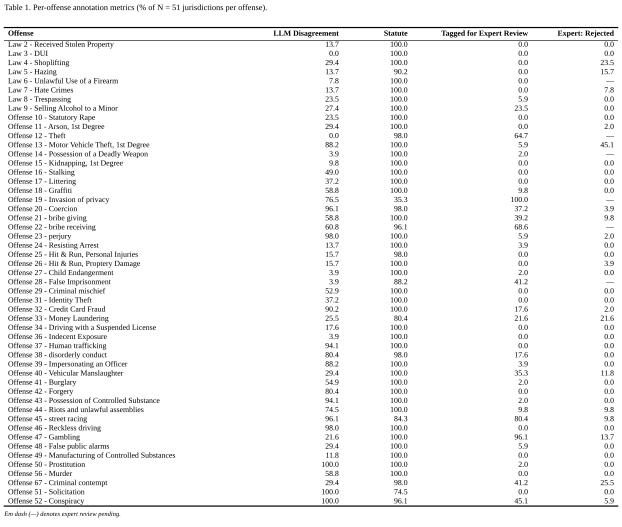

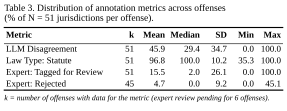

In [16]:
df = run('/Users/chris/Desktop/Compiled_Metric_Analysis (2).xlsx')

In [13]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.
